Iteration 2: ||L_2 - L_1|| = 5.662289e+00
Iteration 3: ||L_3 - L_2|| = 1.633171e+01
Iteration 4: ||L_4 - L_3|| = 4.851014e+01
Iteration 5: ||L_5 - L_4|| = 1.450895e+02
Iteration 6: ||L_6 - L_5|| = 4.348482e+02
Iteration 7: ||L_7 - L_6|| = 1.304143e+03
Iteration 8: ||L_8 - L_7|| = 3.912049e+03
Iteration 9: ||L_9 - L_8|| = 1.173579e+04
Iteration 10: ||L_10 - L_9|| = 3.520703e+04
Iteration 11: ||L_11 - L_10|| = 1.056208e+05
Iteration 12: ||L_12 - L_11|| = 3.168621e+05
Iteration 13: ||L_13 - L_12|| = 9.505860e+05
Iteration 14: ||L_14 - L_13|| = 2.851758e+06
Iteration 15: ||L_15 - L_14|| = 8.555273e+06
Iteration 16: ||L_16 - L_15|| = 2.566582e+07
Iteration 17: ||L_17 - L_16|| = 7.699745e+07
Iteration 18: ||L_18 - L_17|| = 2.309924e+08
Iteration 19: ||L_19 - L_18|| = 6.929771e+08
Iteration 20: ||L_20 - L_19|| = 2.078931e+09
Iteration 21: ||L_21 - L_20|| = 6.236794e+09
Iteration 22: ||L_22 - L_21|| = 1.871038e+10
Iteration 23: ||L_23 - L_22|| = 5.613114e+10
Iteration 24: ||L_24 - L_23|| = 1.6

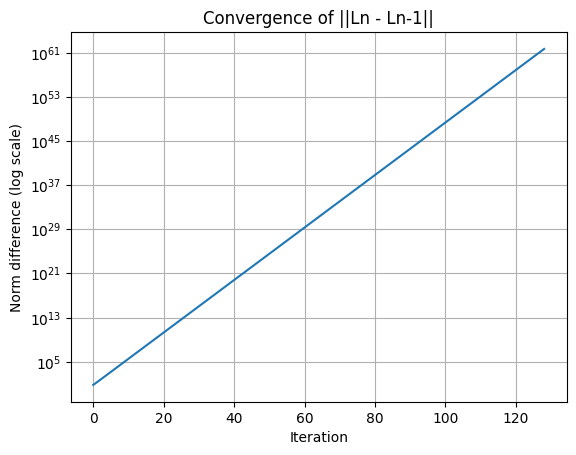

In [ ]:
#Main
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

I = np.eye(2)
L = 2 * I
tol = 1e-5
max_iter =130

X = np.array([
  [1,1],
  [0,1]
])

# function
def f_X(L):
  term1 = sqrtm(sqrtm(L) @ X.conj().T @ L @ X @ sqrtm(L) + 0.25 * I)
  term2 = sqrtm(sqrtm(L) @ X @ L @ X.conj().T @ sqrtm(L) + 0.25 * I)
  Lk= I + term1 + term2
  finalmat= (Lk + Lk.conj().T)/2
  return finalmat

import numpy as np

def sqrtm(X):
  evals, evecs = np.linalg.eigh(X)
  evals_clipped = np.clip(evals,0,None)
  sqrt_evals = np.sqrt(evals_clipped)
  sqrtX = evecs @ np.diag(sqrt_evals) @ evecs.conj().T
  finalsqrt= (sqrtX + sqrtX.conj().T)/2
  return finalsqrt


#Convergence
sequence = [L]
norm_diffs = []

for k in range(1, max_iter):
  L_new = f_X(L)
  diff= L_new - L
  finaldiff= (diff + diff.conj().T)/2
  diff_norm = np.linalg.norm(finaldiff, ord='fro')
  norm_diffs.append(diff_norm)
  print(f"Iteration {k+1}: ||L_{k+1} - L_{k}|| = {diff_norm:.6e}")

  if diff_norm < tol:
    print(f"Converged at iteration {k+1}")
    break

  sequence.append(L_new)
  L = L_new

N = len(sequence)



# positive semidefiniteness
print("\nChecking positive semidefiniteness of differences:")
for k in range(1, N):
  D = sequence[k]-sequence[k-1]
  eigvals = np.linalg.eigvals(D)
  if np.all(eigvals.real >= -1e-10):
    print(f"L_{k+1}-L_{k} is positive semidefinite")
  else:
    print(f"L_{k+1}-L_{k} is NOT positive semidefinite")
    print (eigvals)


print("\nFinal L (limit matrix):")
print(np.round(L.real, 6))
plt.semilogy(norm_diffs)
plt.title('Convergence of ||Ln - Ln-1||')
plt.xlabel('Iteration')
plt.ylabel('Norm difference (log scale)')
plt.grid(True)
plt.show()


In [ ]:
#Using Definiton of Numerical Radius
def numerical_radius(X):
  n = X.shape[0]
  if X.shape[0] != X.shape[1]:
    raise ValueError("Matrix must be square.")

  def objective(v):
    x = v[:n] + 1j * v[n:]
    x = x / np.linalg.norm(x)
    return -abs(np.vdot(x, X @ x))

  v0 = np.random.randn(2*n)
  v0 /= np.linalg.norm(v0)

  def constraint(v):
    x = v[:n] + 1j * v[n:]
    return np.linalg.norm(x) - 1

  cons = {'type': 'eq', 'fun': constraint}
  res = minimize(objective, v0, constraints=cons, method='SLSQP', options={'disp': False})

  if not res.success:
    raise RuntimeError("Optimization failed: " + res.message)

  x_opt = res.x[:n] + 1j * res.x[n:]
  x_opt /= np.linalg.norm(x_opt)
  return abs(np.vdot(x_opt, X @ x_opt))

# Compute the numerical radius
w = numerical_radius(X)
print("w(X):", w)


w(X): 1.4999999999636515


In [ ]:
#Using Real and Imaginary Decomposition

def numerical_radius(X, num_starts=50):
  n = X.shape[0]
  if X.shape[0] != X.shape[1]:
    raise ValueError("Matrix must be square.")

  ReX = np.real(X)
  ImX = np.imag(X)

    # Objective function using ReX and ImX
  def objective(v):
    x = v[:n] + 1j * v[n:]  # reconstruct complex vector
    real_part = np.abs(np.conj(x).T @ ReX @ x)
    imag_part = np.abs(np.conj(x).T @ ImX @ x)
    return -np.sqrt(real_part**2 + imag_part**2)  # negative for maximization

    # Constraint: ||x|| = 1
  def constraint(v):
    x = v[:n] + 1j * v[n:]
    return np.real(np.vdot(x, x)) - 1.0

  cons = {'type': 'eq', 'fun': constraint}

  best_wX = 0
  for _ in range(num_starts):
    # Random complex initial vector
    v0 = np.random.randn(2 * n)
    v0 /= np.linalg.norm(v0)

    res = minimize(objective, v0, method='SLSQP', constraints=cons, options={'disp': False, 'maxiter': 1000, 'ftol': 1e-9})

    if res.success:
      x_opt = res.x[:n] + 1j * res.x[n:]
      x_opt /= np.linalg.norm(x_opt)
      real_part =np.abs( np.conj(x_opt).T @ ReX @ x_opt)
      imag_part = np.abs(np.conj(x_opt).T @ ImX @ x_opt)
      wX = np.sqrt(real_part**2 + imag_part**2)
      best_wX = max(best_wX, wX)

  return best_wX

w_X = numerical_radius(X, num_starts=50)
print("Numerical Radius:", w_X)

Numerical Radius: 1.5000000000000004


In [ ]:
#Supporting line
import numpy as np
from scipy.optimize import minimize

def numerical_radius_theta_slsqp(A, theta0=0.0, verbose=False):

  A = np.asarray(A, dtype=complex)

  def H_theta(theta):
    t = float(theta[0]) if np.ndim(theta) else float(theta)
    E = np.exp(1j * t) * A
    return (E + E.conj().T) / 2.0

  def lambda_max_theta(theta):
    H = H_theta(theta)
    return np.linalg.eigvalsh(H)[-1].real

  def objective(theta):
    return -lambda_max_theta(theta)   # maximize lambda_max

  bounds = [(0.0, 2.0 * np.pi)]

  result = minimize(
    objective,
    x0=np.array([theta0], dtype=float),
    method="SLSQP",
    bounds=bounds,
    options={
      "maxiter": 1000,
      "ftol": 1e-12,
      "disp": verbose
    }
  )

  theta_opt = float(result.x[0])
  H_opt = H_theta(theta_opt)
  eigvals_opt = np.linalg.eigvalsh(H_opt)
  w_opt = eigvals_opt[-1].real

  return {
    "w": w_opt,
    "theta": theta_opt,
    "H": H_opt,
    "eigvals": eigvals_opt,
    "status": result.status,
    "success": result.success,
    "message": result.message,
    "nit": result.nit,
  }


if __name__ == "__main__":
  A = np.array([
    [1, 1],
    [0, 1]
  ], dtype=complex)

  out = numerical_radius_theta_slsqp(A, theta0=0.5, verbose=True)

  print("success:", out["success"])
  print("message:", out["message"])
  print("theta* =", out["theta"])
  print("w(A) ≈", out["w"])
  print("eigvals of Re(e^{i theta}A) =\n", out["eigvals"])
  print("Re(e^{i theta}A) =\n", out["H"])

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1.5
            Iterations: 3
            Function evaluations: 6
            Gradient evaluations: 3
success: True
message: Optimization terminated successfully
theta* = 0.0
w(A) ≈ 1.5
eigvals of Re(e^{i theta}A) =
 [0.5 1.5]
Re(e^{i theta}A) =
 [[1. +0.j 0.5+0.j]
 [0.5+0.j 1. +0.j]]


In [ ]:
#Scalar Bound Formulation
import numpy as np
from scipy.optimize import minimize

def numerical_radius_slsqp(A, x0=None, verbose=False):
  A = np.asarray(A, dtype=complex)
  n = A.shape[0]

  def unpack(y):
    u = y[:n]
    v = y[n:]
    return u + 1j * v

  def objective(y):
    x = unpack(y)
    z = np.vdot(x, A @ x)
    return -abs(z)   # maximize |x*Ax|

  def norm_constraint(y):
    x = unpack(y)
    return np.vdot(x, x).real - 1.0

  if x0 is None:
    x = np.random.randn(n) + 1j * np.random.randn(n)
  else:
    x = np.asarray(x0, dtype=complex)

  x = x / np.linalg.norm(x)
  y0 = np.concatenate([x.real, x.imag])

  constraints = [
    {"type": "eq", "fun": norm_constraint}
  ]

  result = minimize(
    objective,
    y0,
    method="SLSQP",
    constraints=constraints,
    options={
      "maxiter": 1000,
      "ftol": 1e-12,
      "disp": verbose}
    )

  x_opt = unpack(result.x)
  z_opt = np.vdot(x_opt, A @ x_opt)

  return {
    "x": x_opt,
    "w_approx": abs(z_opt),
    "xAx": z_opt,
    "success": result.success,
    "status": result.status,
    "message": result.message,
    "nit": result.nit,
    "fun": result.fun,
  }

if __name__ == "__main__":
  A = np.array([
    [1, 1],
    [0, 1]
  ], dtype=complex)

  out = numerical_radius_slsqp(A, verbose=True)

  print("success:", out["success"])
  print("message:", out["message"])
  print("w(A) ≈", out["w_approx"])
  print("x*Ax =", out["xAx"])
  print("x =\n", out["x"])

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1.5000000000000129
            Iterations: 9
            Function evaluations: 45
            Gradient evaluations: 9
success: True
message: Optimization terminated successfully
w(A) ≈ 1.5000000000000129
x*Ax = (1.5000000000000129+6.593909307461843e-09j)
x =
 [0.38824951-0.59098419j 0.38824952-0.59098419j]


In [ ]:
#Ando's Theorem Formulation
import numpy as np
import cvxpy as cp

def minr(A, solver=cp.SCS, verbose=False):

  n = A.shape[0]
  r = cp.Variable(name="r")
  r.value = np.linalg.norm(A, 2)

  X = cp.Variable((n, n), hermitian=True)
  minus= r * np.eye(n) - X
  plus= r * np.eye(n) + X
  top = [minus, A]
  bottom = [A.conj().T, plus]
  main = cp.bmat([top, bottom])

  constraints = [
  main >> 0,
  r >= 0]

  obj = cp.Minimize(r)
  prob = cp.Problem(obj, constraints)

  prob.solve(solver=solver, verbose=verbose)

  return {"r": None if r.value is None else float(np.real(r.value)),
    "X": None if X.value is None else X.value,
    "status": prob.status,
    "solver": prob.solver_stats.solver_name}

if __name__ == "__main__":
  A = np.array([
  [1,1],
  [0,1]
], dtype=complex)
  out = minr(A, solver=cp.SCS, verbose=True)
  print("status:", out["status"], "solver:", out["solver"])
  print("r =", out["r"])
  print("X =\n", out["X"])


(CVXPY) Apr 18 05:12:30 PM: Your problem has 5 variables, 17 constraints, and 0 parameters.
(CVXPY) Apr 18 05:12:30 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 18 05:12:30 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 18 05:12:30 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 18 05:12:30 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 18 05:12:30 PM: Compiling problem (target solver=SCS).
(CVXPY) Apr 18 05:12:30 PM: Reduction chain: Complex2Real -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Apr 18 05:12:30 PM: Applying reduction Complex2Real
(CVXPY) Apr 18 05:12:30 PM: Applying reduction Dcp2Cone
(CVXPY) Apr 18 05:12:30 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 18 05:12:30 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 18 05:12:30 PM: Applying reducti

                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 5, constraints m: 37
cones: 	  l: linear vars: 1
	  s: psd vars: 36, ssize: 1
settings: eps_abs: 1.0e-05, e

(CVXPY) Apr 18 05:12:30 PM: Problem status: optimal
(CVXPY) Apr 18 05:12:30 PM: Optimal value: 1.500e+00
(CVXPY) Apr 18 05:12:30 PM: Compilation took 1.507e-01 seconds
(CVXPY) Apr 18 05:12:30 PM: Solver (including time spent in interface) took 4.204e-02 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
status: optimal solver: SCS
r = 1.5000031287992108
X =
 [[-4.99999607e-01+0.j  1.26570635e-13+0.j]
 [ 1.26570635e-13+0.j  4.99999607e-01+0.j]]


The following codes are numerical experiments searching for characteristic of X such that {$L_k^\frac{1}{2}yy^*L_k^\frac{1}{2}$} is an increasing sequence.

In [ ]:
#rank1
import numpy as np


def sqrtm(X):
  evals, evecs = np.linalg.eigh(X)
  evals_clipped = np.clip(evals, 0, None)
  sqrt_evals = np.sqrt(evals_clipped)
  sqrtX = evecs @ np.diag(sqrt_evals) @ evecs.conj().T
  finalsqrt= (sqrtX + sqrtX.conj().T)/2
  return finalsqrt


def f_X(L, X):
  I = np.eye(n, dtype=complex)
  term1 = sqrtm(sqrtm(L) @ X.conj().T @ L @ X @ sqrtm(L) + 0.25 * I)
  term2 = sqrtm(sqrtm(L) @ X @ L @ X.conj().T @ sqrtm(L) + 0.25 * I)
  Lk= I + term1 + term2
  finalmat= (Lk + Lk.conj().T)/2
  return finalmat


def generate_sequence(X, n, max_iter=20, tol=1e-8):
  I = np.eye(n, dtype=complex)

  L = 2 * I
  sequence = [L]

  for k in range(max_iter):
    L_new = f_X(L, X)
    diff_norm = np.linalg.norm(L_new - L, ord='fro')

    sequence.append(L_new)

    if diff_norm < tol:
      break

    L = L_new

  return sequence


def check_rank_one_psd(sequence, y):
  N = len(sequence)

  print("\nChecking positive semidefiniteness of differences:")

  for k in range(1, N):
    Lk_sqrt   = sqrtm(sequence[k])
    Lkm1_sqrt = sqrtm(sequence[k-1])

    herm_err = np.linalg.norm(Lk_sqrt - Lk_sqrt.conj().T)
    print(f"k={k}: ||L_k^{1/2} - (L_k^{1/2})*|| = {herm_err:.2e}")

    Ak   = Lk_sqrt @ np.outer(y, y.conj()) @ Lk_sqrt
    Akm1 = Lkm1_sqrt @ np.outer(y, y.conj()) @ Lkm1_sqrt

    D = Ak - Akm1
    D = (D + D.conj().T) / 2

    eigvals = np.linalg.eigvals(D)

    if np.all(eigvals.real >= -1e-10):
      print(f"A_{k+1} - A_{k} is positive semidefinite")
    else:
      print(f"A_{k+1} - A_{k} is NOT positive semidefinite")
      print(f"eigenvalues: {eigvals}")




n = 2

x_raw = np.random.randn(n) + 1j * np.random.randn(n)
y_raw = np.random.randn(n) + 1j * np.random.randn(n)

x = x_raw / np.linalg.norm(x_raw)
y = y_raw / np.linalg.norm(y_raw)

X = np.outer(x, y.conj())
w_X = (np.linalg.norm(x) * np.linalg.norm(y) + np.abs(y.conj() @ x)) / 2
print(f"Numerical Radius w(X) = {w_X:.4f}")
print("x=", x)
print("y=", y)
print ("X=", X)


sequence = generate_sequence(X, n, max_iter=30, tol=1e-8)
check_rank_one_psd(sequence, y)


Numerical Radius w(X) = 0.9086
x= [ 0.27221847+0.91550011j -0.17230965+0.24096896j]
y= [0.37639793-0.50027837j 0.72005173-0.29928524j]
X= [[-0.35554243+0.48077736j -0.07798429+0.74067841j]
 [-0.18540856+0.00449743j -0.19619032+0.12194038j]]

Checking positive semidefiniteness of differences:
k=1: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_2 - A_1 is NOT positive semidefinite
eigenvalues: [ 2.63399412-5.524491e-17j -0.02982731+5.524491e-17j]
k=2: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_3 - A_2 is NOT positive semidefinite
eigenvalues: [ 4.62969398-1.08869853e-16j -0.03339594+1.08869853e-16j]
k=3: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_4 - A_3 is NOT positive semidefinite
eigenvalues: [ 8.33147033+8.33546453e-17j -0.03367559+1.38689960e-16j]
k=4: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_5 - A_4 is NOT positive semidefinite
eigenvalues: [15.08583563-3.18104939e-16j -0.03352075-5.70073481e-16j]
k=5: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_6 - A_5 is NOT positive semidefinite
eigenvalues: [27.37198519-8

In [ ]:
#rank 1, w(X)< 1/2
import numpy as np


def sqrtm(X):
  evals, evecs = np.linalg.eigh(X)
  evals_clipped = np.clip(evals, 0, None)
  sqrt_evals = np.sqrt(evals_clipped)
  sqrtX = evecs @ np.diag(sqrt_evals) @ evecs.conj().T
  finalsqrt= (sqrtX + sqrtX.conj().T)/2
  return finalsqrt


def f_X(L, X):
  I = np.eye(n, dtype=complex)
  term1 = sqrtm(sqrtm(L) @ X.conj().T @ L @ X @ sqrtm(L) + 0.25 * I)
  term2 = sqrtm(sqrtm(L) @ X @ L @ X.conj().T @ sqrtm(L) + 0.25 * I)
  Lk= I + term1 + term2
  finalmat= (Lk + Lk.conj().T)/2
  return finalmat


def generate_sequence(X, n, max_iter=20, tol=1e-8):
  I = np.eye(n, dtype=complex)

  L = 2 * I
  sequence = [L]

  for k in range(max_iter):
    L_new = f_X(L, X)
    diff_norm = np.linalg.norm(L_new - L, ord='fro')
    sequence.append(L_new)
    if diff_norm < tol:
      break

    L = L_new

  return sequence


def check_rank_one_psd(sequence, y):
  N = len(sequence)

  print("\nChecking positive semidefiniteness of differences:")

  for k in range(1, N):
    Lk_sqrt   = sqrtm(sequence[k])
    Lkm1_sqrt = sqrtm(sequence[k-1])

    herm_err = np.linalg.norm(Lk_sqrt - Lk_sqrt.conj().T)
    print(f"k={k}: ||L_k^{1/2} - (L_k^{1/2})*|| = {herm_err:.2e}")

    Ak   = Lk_sqrt @ np.outer(y, y.conj()) @ Lk_sqrt
    Akm1 = Lkm1_sqrt @ np.outer(y, y.conj()) @ Lkm1_sqrt

    D = Ak - Akm1
    D = (D + D.conj().T) / 2

    eigvals = np.linalg.eigvals(D)

    if np.all(eigvals.real >= -1e-10):
      print(f"A_{k+1} - A_{k} is positive semidefinite")
    else:
      print(f"A_{k+1} - A_{k} is NOT positive semidefinite")
      print(f"eigenvalues: {eigvals}")




n=2
x_raw = np.random.randn(n) + 1j * np.random.randn(n)
y_raw = np.random.randn(n) + 1j * np.random.randn(n)

x_unit = x_raw / np.linalg.norm(x_raw)
y_unit = y_raw / np.linalg.norm(y_raw)

x = 0.6 * x_unit
y = 0.8 * y_unit

X = np.outer(x, y.conj())

w_X = (np.linalg.norm(x) * np.linalg.norm(y) + np.abs(y.conj() @ x)) / 2
print(f"Numerical Radius w(X) = {w_X:.4f}")
print("x=", x)
print("y=", y)
print ("X=", X)

sequence = generate_sequence(X, n, max_iter=30, tol=1e-8)
check_rank_one_psd(sequence, y)

Numerical Radius w(X) = 0.3838
x= [ 0.13875611+0.12028318j -0.49111074-0.29170009j]
y= [ 0.36941496-0.35652915j -0.06814505-0.60973421j]
X= [[ 0.00837412+0.093905j   -0.08279631+0.07640764j]
 [-0.07742407-0.28285367j  0.21132629-0.2795691j ]]

Checking positive semidefiniteness of differences:
k=1: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_2 - A_1 is NOT positive semidefinite
eigenvalues: [-0.0119934 +0.j  0.51858752+0.j]
k=2: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_3 - A_2 is NOT positive semidefinite
eigenvalues: [-0.00974687+6.04472826e-18j  0.34085022+2.17108474e-17j]
k=3: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_4 - A_3 is NOT positive semidefinite
eigenvalues: [-0.00680258+5.58021973e-18j  0.23725562+2.21753559e-17j]
k=4: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_5 - A_4 is NOT positive semidefinite
eigenvalues: [-0.00468287+5.47572581e-18j  0.16898895-5.47572581e-18j]
k=5: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_6 - A_5 is NOT positive semidefinite
eigenvalues: [-0.00326219-2.61235308e-18j  0.

In [ ]:
#rank 1,orthogonal
import numpy as np


def sqrtm(X):
  evals, evecs = np.linalg.eigh(X)
  evals_clipped = np.clip(evals, 0, None)
  sqrt_evals = np.sqrt(evals_clipped)
  sqrtX = evecs @ np.diag(sqrt_evals) @ evecs.conj().T
  finalsqrt= (sqrtX + sqrtX.conj().T)/2
  return finalsqrt


def f_X(L, X):
  I = np.eye(n, dtype=complex)
  term1 = sqrtm(sqrtm(L) @ X.conj().T @ L @ X @ sqrtm(L) + 0.25 * I)
  term2 = sqrtm(sqrtm(L) @ X @ L @ X.conj().T @ sqrtm(L) + 0.25 * I)
  Lk= I + term1 + term2
  finalmat= (Lk + Lk.conj().T)/2
  return finalmat


def generate_sequence(X, n, max_iter=20, tol=1e-8):
  I = np.eye(n, dtype=complex)

  L = 2 * I
  sequence = [L]

  for k in range(max_iter):
    L_new = f_X(L, X)
    diff_norm = np.linalg.norm(L_new - L, ord='fro')

    sequence.append(L_new)

    if diff_norm < tol:
      break

    L = L_new

  return sequence


def check_rank_one_psd(sequence, y):
  N = len(sequence)

  print("\nChecking positive semidefiniteness of differences:")

  for k in range(1, N):
    Lk_sqrt   = sqrtm(sequence[k])
    Lkm1_sqrt = sqrtm(sequence[k-1])

    herm_err = np.linalg.norm(Lk_sqrt - Lk_sqrt.conj().T)
    print(f"k={k}: ||L_k^{1/2} - (L_k^{1/2})*|| = {herm_err:.2e}")

    Ak   = Lk_sqrt @ np.outer(y, y.conj()) @ Lk_sqrt
    Akm1 = Lkm1_sqrt @ np.outer(y, y.conj()) @ Lkm1_sqrt

    D = Ak - Akm1
    D = (D + D.conj().T) / 2

    eigvals = np.linalg.eigvals(D)

    if np.all(eigvals.real >= -1e-10):
      print(f"A_{k+1} - A_{k} is positive semidefinite")
    else:
      print(f"A_{k+1} - A_{k} is NOT positive semidefinite")
      print(f"eigenvalues: {eigvals}")




n=2

x_raw = np.random.randn(n) + 1j * np.random.randn(n)
x = x_raw / np.linalg.norm(x_raw)

y_raw = np.random.randn(n) + 1j * np.random.randn(n)

# Gram–Schmidt step: make y ⟂ x
y_orth = y_raw - (x_unit.conj() @ y_raw) * x_unit
y = y_orth / np.linalg.norm(y_orth)

X = np.outer(x, y.conj())

w_X = (np.linalg.norm(x) * np.linalg.norm(y) + np.abs(y.conj() @ x)) / 2
print(f"Numerical Radius w(X) = {w_X:.4f}")
print("x=", x)
print("y=", y)
print("X=", X)
print("⟨y, x⟩ =", y.conj() @ x)
print("‖x‖ =", np.linalg.norm(x))
print("‖y‖ =", np.linalg.norm(y))

sequence = generate_sequence(X, n, max_iter=30, tol=1e-8)
check_rank_one_psd(sequence, y)

Numerical Radius w(X) = 0.7997
x= [-0.29229972-0.47531819j -0.64367578+0.52375087j]
y= [0.68891209+0.65706153j 0.25541583+0.16862099j]
X= [[-0.51368211-0.13539355j -0.1548066 -0.07211592j]
 [-0.09929948+0.7837529j  -0.07608959+0.24231151j]]
⟨y, x⟩ = (-0.5897716998163497+0.10691796018968058j)
‖x‖ = 1.0
‖y‖ = 1.0

Checking positive semidefiniteness of differences:
k=1: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_2 - A_1 is NOT positive semidefinite
eigenvalues: [ 2.15969965+4.39090749e-17j -0.03714008-1.61534993e-17j]
k=2: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_3 - A_2 is NOT positive semidefinite
eigenvalues: [ 3.21669927+9.84235664e-17j -0.05569128-4.29124151e-17j]
k=3: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_4 - A_3 is NOT positive semidefinite
eigenvalues: [ 5.00143215+0.j -0.06541108+0.j]
k=4: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_5 - A_4 is NOT positive semidefinite
eigenvalues: [ 7.8977282 +2.44989014e-16j -0.07062175-2.29444088e-17j]
k=5: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_6 - A_5 is N

In [ ]:
#rank 1, orthogonal, w(X)<1/2
import numpy as np


def sqrtm(X):
  evals, evecs = np.linalg.eigh(X)
  evals_clipped = np.clip(evals, 0, None)
  sqrt_evals = np.sqrt(evals_clipped)
  sqrtX = evecs @ np.diag(sqrt_evals) @ evecs.conj().T
  finalsqrt= (sqrtX + sqrtX.conj().T)/2
  return finalsqrt


def f_X(L, X):
  I = np.eye(n, dtype=complex)
  term1 = sqrtm(sqrtm(L) @ X.conj().T @ L @ X @ sqrtm(L) + 0.25 * I)
  term2 = sqrtm(sqrtm(L) @ X @ L @ X.conj().T @ sqrtm(L) + 0.25 * I)
  Lk= I + term1 + term2
  finalmat= (Lk + Lk.conj().T)/2
  return finalmat


def generate_sequence(X, n, max_iter=20, tol=1e-8):
  I = np.eye(n, dtype=complex)

  L = 2 * I
  sequence = [L]

  for k in range(max_iter):
    L_new = f_X(L, X)
    diff_norm = np.linalg.norm(L_new - L, ord='fro')

    sequence.append(L_new)

    if diff_norm < tol:
      break

    L = L_new

  return sequence


def check_rank_one_psd(sequence, y):
  N = len(sequence)

  print("\nChecking positive semidefiniteness of differences:")

  for k in range(1, N):
    Lk_sqrt   = sqrtm(sequence[k])
    Lkm1_sqrt = sqrtm(sequence[k-1])

    herm_err = np.linalg.norm(Lk_sqrt - Lk_sqrt.conj().T)
    print(f"k={k}: ||L_k^{1/2} - (L_k^{1/2})*|| = {herm_err:.2e}")

    Ak   = Lk_sqrt @ np.outer(y, y.conj()) @ Lk_sqrt
    Akm1 = Lkm1_sqrt @ np.outer(y, y.conj()) @ Lkm1_sqrt

    D = Ak - Akm1
    D = (D + D.conj().T) / 2

    eigvals = np.linalg.eigvals(D)

    if np.all(eigvals.real >= -1e-10):
      print(f"A_{k+1} - A_{k} is positive semidefinite")
    else:
      print(f"A_{k+1} - A_{k} is NOT positive semidefinite")
      print(f"eigenvalues: {eigvals}")





n = 2

x_raw = np.random.randn(n) + 1j * np.random.randn(n)
x_unit = x_raw / np.linalg.norm(x_raw)

y_raw = np.random.randn(n) + 1j * np.random.randn(n)

# Gram–Schmidt step: make y ⟂ x
y_orth = y_raw - (x_unit.conj() @ y_raw) * x_unit
y_unit = y_orth / np.linalg.norm(y_orth)

x = 0.6 * x_unit
y = 0.8 * y_unit

X = np.outer(x, y.conj())

w_X = (np.linalg.norm(x) * np.linalg.norm(y) + np.abs(y.conj() @ x)) / 2
print(f"Numerical Radius w(X) = {w_X:.4f}")
print("x=", x)
print("y=", y)
print("X=", X)
print("⟨y, x⟩ =", y.conj() @ x)
print("‖x‖ =", np.linalg.norm(x))
print("‖y‖ =", np.linalg.norm(y))

sequence = generate_sequence(X, n, max_iter=30, tol=1e-8)
check_rank_one_psd(sequence, y)

Numerical Radius w(X) = 0.2400
x= [-0.2703593 +0.33391071j  0.27680574+0.30919645j  0.05425131+0.01556976j]
y= [-0.21119101+0.20539233j -0.2625493 -0.2320575j   0.47532765-0.45220919j]
X= [[ 0.12568015-0.01498921j -0.00650384-0.15040693j -0.27950674+0.03645803j]
 [ 0.0050477 -0.12215329j -0.14442651-0.01694446j -0.00824805+0.27214372j]
 [-0.00825948-0.014431j   -0.01785672+0.00850159j  0.01874636+0.03193368j]]
⟨y, x⟩ = (-2.7755575615628914e-17-2.7755575615628914e-17j)
‖x‖ = 0.5999999999999999
‖y‖ = 0.8

Checking positive semidefiniteness of differences:
k=1: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_2 - A_1 is positive semidefinite
k=2: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_3 - A_2 is positive semidefinite
k=3: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_4 - A_3 is positive semidefinite
k=4: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_5 - A_4 is positive semidefinite
k=5: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_6 - A_5 is positive semidefinite
k=6: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_7 - A_6 is positi

The following codes are numerical experiments searching for characteristic of X such that {$L_k^\frac{1}{2}xx^*L_k^\frac{1}{2}$} is an increasing sequence.

In [ ]:
#rank1
import numpy as np


def sqrtm(X):
  evals, evecs = np.linalg.eigh(X)
  evals_clipped = np.clip(evals, 0, None)
  sqrt_evals = np.sqrt(evals_clipped)
  sqrtX = evecs @ np.diag(sqrt_evals) @ evecs.conj().T
  finalsqrt= (sqrtX + sqrtX.conj().T)/2
  return finalsqrt


def f_X(L, X):
  I = np.eye(n, dtype=complex)
  term1 = sqrtm(sqrtm(L) @ X.conj().T @ L @ X @ sqrtm(L) + 0.25 * I)
  term2 = sqrtm(sqrtm(L) @ X @ L @ X.conj().T @ sqrtm(L) + 0.25 * I)
  Lk= I + term1 + term2
  finalmat= (Lk + Lk.conj().T)/2
  return finalmat


def generate_sequence(X, n, max_iter=20, tol=1e-8):
  I = np.eye(n, dtype=complex)

  L = 2 * I
  sequence = [L]

  for k in range(max_iter):
    L_new = f_X(L, X)
    diff_norm = np.linalg.norm(L_new - L, ord='fro')

    sequence.append(L_new)

    if diff_norm < tol:
      break

    L = L_new

  return sequence


def check_rank_one_psd(sequence, y):
  N = len(sequence)

  print("\nChecking positive semidefiniteness of differences:")

  for k in range(1, N):
    Lk_sqrt   = sqrtm(sequence[k])
    Lkm1_sqrt = sqrtm(sequence[k-1])

    herm_err = np.linalg.norm(Lk_sqrt - Lk_sqrt.conj().T)
    print(f"k={k}: ||L_k^{1/2} - (L_k^{1/2})*|| = {herm_err:.2e}")

    Ak   = Lk_sqrt @ np.outer(x, x.conj()) @ Lk_sqrt
    Akm1 = Lkm1_sqrt @ np.outer(x, x.conj()) @ Lkm1_sqrt

    D = Ak - Akm1
    D = (D + D.conj().T) / 2

    eigvals = np.linalg.eigvals(D)

    if np.all(eigvals.real >= -1e-10):
      print(f"A_{k+1} - A_{k} is positive semidefinite")
    else:
      print(f"A_{k+1} - A_{k} is NOT positive semidefinite")
      print(f"eigenvalues: {eigvals}")


n = 2

x_raw = np.random.randn(n) + 1j * np.random.randn(n)
y_raw = np.random.randn(n) + 1j * np.random.randn(n)


x = x_raw / np.linalg.norm(x_raw)
y = y_raw / np.linalg.norm(y_raw)

X = np.outer(x, y.conj())
w_X = (np.linalg.norm(x) * np.linalg.norm(y) + np.abs(y.conj() @ x)) / 2
print(f"Numerical Radius w(X) = {w_X:.4f}")
print("x=", x)
print("y=", y)
print ("X=", X)

sequence = generate_sequence(X, n, max_iter=30, tol=1e-8)
check_rank_one_psd(sequence, y)


Numerical Radius w(X) = 0.6429
x= [ 0.11730454+0.53434245j -0.83192355+0.09284931j]
y= [-0.65747047-0.22893625j -0.52655814+0.48791117j]
X= [[-0.19945463-0.32445912j  0.19894399-0.33859656j]
 [ 0.52570859-0.25150313j  0.48335833+0.35701423j]]

Checking positive semidefiniteness of differences:
k=1: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_2 - A_1 is NOT positive semidefinite
eigenvalues: [-0.01512369-4.90953919e-17j  1.70419469-1.72949213e-16j]
k=2: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_3 - A_2 is NOT positive semidefinite
eigenvalues: [-0.03273861+0.j  1.93194961+0.j]
k=3: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_4 - A_3 is NOT positive semidefinite
eigenvalues: [-0.05080166+3.30133120e-17j  2.29740937+1.89031293e-16j]
k=4: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_5 - A_4 is NOT positive semidefinite
eigenvalues: [-0.06750429+3.75822372e-17j  2.80776341-3.75822372e-17j]
k=5: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_6 - A_5 is NOT positive semidefinite
eigenvalues: [-0.08217732+0.j  3.49014177+0.j

In [ ]:
#rank 1, w(X)< 1/2
import numpy as np


def sqrtm(X):
  evals, evecs = np.linalg.eigh(X)
  evals_clipped = np.clip(evals, 0, None)
  sqrt_evals = np.sqrt(evals_clipped)
  sqrtX = evecs @ np.diag(sqrt_evals) @ evecs.conj().T
  finalsqrt= (sqrtX + sqrtX.conj().T)/2
  return finalsqrt


def f_X(L, X):
  I = np.eye(n, dtype=complex)
  term1 = sqrtm(sqrtm(L) @ X.conj().T @ L @ X @ sqrtm(L) + 0.25 * I)
  term2 = sqrtm(sqrtm(L) @ X @ L @ X.conj().T @ sqrtm(L) + 0.25 * I)
  Lk= I + term1 + term2
  finalmat= (Lk + Lk.conj().T)/2
  return finalmat


def generate_sequence(X, n, max_iter=20, tol=1e-8):
  I = np.eye(n, dtype=complex)

  L = 2 * I
  sequence = [L]

  for k in range(max_iter):
    L_new = f_X(L, X)
    diff_norm = np.linalg.norm(L_new - L, ord='fro')

    sequence.append(L_new)

    if diff_norm < tol:
      break

    L = L_new

  return sequence


def check_rank_one_psd(sequence, y):
  N = len(sequence)

  print("\nChecking positive semidefiniteness of differences:")

  for k in range(1, N):
    Lk_sqrt   = sqrtm(sequence[k])
    Lkm1_sqrt = sqrtm(sequence[k-1])

    herm_err = np.linalg.norm(Lk_sqrt - Lk_sqrt.conj().T)
    print(f"k={k}: ||L_k^{1/2} - (L_k^{1/2})*|| = {herm_err:.2e}")

    Ak   = Lk_sqrt @ np.outer(x, x.conj()) @ Lk_sqrt
    Akm1 = Lkm1_sqrt @ np.outer(x, x.conj()) @ Lkm1_sqrt

    D = Ak - Akm1
    D = (D + D.conj().T) / 2

    eigvals = np.linalg.eigvals(D)

    if np.all(eigvals.real >= -1e-10):
      print(f"A_{k+1} - A_{k} is positive semidefinite")
    else:
      print(f"A_{k+1} - A_{k} is NOT positive semidefinite")
      print(f"eigenvalues: {eigvals}")


n=2
x_raw = np.random.randn(n) + 1j * np.random.randn(n)
y_raw = np.random.randn(n) + 1j * np.random.randn(n)

x_unit = x_raw / np.linalg.norm(x_raw)
y_unit = y_raw / np.linalg.norm(y_raw)

x = 0.6 * x_unit
y = 0.8 * y_unit

X = np.outer(x, y.conj())

w_X = (np.linalg.norm(x) * np.linalg.norm(y) + np.abs(y.conj() @ x)) / 2
print(f"Numerical Radius w(X) = {w_X:.4f}")
print("x=", x)
print("y=", y)
print ("X=", X)

sequence = generate_sequence(X, n, max_iter=30, tol=1e-8)
check_rank_one_psd(sequence, y)

Numerical Radius w(X) = 0.4395
x= [0.3129223+0.31993113j 0.220676 -0.33320535j]
y= [ 0.02433632-0.23502286j -0.6879    -0.33311498j]
X= [[-0.06757575+0.08132984j -0.3218331 -0.11584152j]
 [ 0.08368131+0.04375491j -0.04080733+0.30272244j]]

Checking positive semidefiniteness of differences:
k=1: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_2 - A_1 is NOT positive semidefinite
eigenvalues: [-0.0050965 +1.36959843e-17j  0.35967455-1.36959843e-17j]
k=2: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_3 - A_2 is NOT positive semidefinite
eigenvalues: [-0.00351717-1.355742e-17j  0.28367192+1.355742e-17j]
k=3: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_4 - A_3 is NOT positive semidefinite
eigenvalues: [-0.00248528-3.85112838e-18j  0.23468493-2.39044472e-17j]
k=4: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_5 - A_4 is NOT positive semidefinite
eigenvalues: [-0.00185151-5.19920583e-18j  0.19784938-8.67858198e-18j]
k=5: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_6 - A_5 is NOT positive semidefinite
eigenvalues: [-0.00143232+0.j

In [ ]:
#rank 1,orthogonal
import numpy as np


def sqrtm(X):
  evals, evecs = np.linalg.eigh(X)
  evals_clipped = np.clip(evals, 0, None)
  sqrt_evals = np.sqrt(evals_clipped)
  sqrtX = evecs @ np.diag(sqrt_evals) @ evecs.conj().T
  finalsqrt= (sqrtX + sqrtX.conj().T)/2
  return finalsqrt


def f_X(L, X):
  I = np.eye(n, dtype=complex)
  term1 = sqrtm(sqrtm(L) @ X.conj().T @ L @ X @ sqrtm(L) + 0.25 * I)
  term2 = sqrtm(sqrtm(L) @ X @ L @ X.conj().T @ sqrtm(L) + 0.25 * I)
  Lk= I + term1 + term2
  finalmat= (Lk + Lk.conj().T)/2
  return finalmat


def generate_sequence(X, n, max_iter=20, tol=1e-8):
  I = np.eye(n, dtype=complex)

  L = 2 * I
  sequence = [L]

  for k in range(max_iter):
    L_new = f_X(L, X)
    diff_norm = np.linalg.norm(L_new - L, ord='fro')

    sequence.append(L_new)

    if diff_norm < tol:
      break

    L = L_new

  return sequence


def check_rank_one_psd(sequence, y):
  N = len(sequence)

  print("\nChecking positive semidefiniteness of differences:")

  for k in range(1, N):
    Lk_sqrt   = sqrtm(sequence[k])
    Lkm1_sqrt = sqrtm(sequence[k-1])

    herm_err = np.linalg.norm(Lk_sqrt - Lk_sqrt.conj().T)
    print(f"k={k}: ||L_k^{1/2} - (L_k^{1/2})*|| = {herm_err:.2e}")

    Ak   = Lk_sqrt @ np.outer(x, x.conj()) @ Lk_sqrt
    Akm1 = Lkm1_sqrt @ np.outer(x, x.conj()) @ Lkm1_sqrt

    D = Ak - Akm1
    D = (D + D.conj().T) / 2

    eigvals = np.linalg.eigvals(D)

    if np.all(eigvals.real >= -1e-10):
      print(f"A_{k+1} - A_{k} is positive semidefinite")
    else:
      print(f"A_{k+1} - A_{k} is NOT positive semidefinite")
      print(f"eigenvalues: {eigvals}")


n=2

x_raw = np.random.randn(n) + 1j * np.random.randn(n)
x = x_raw / np.linalg.norm(x_raw)

y_raw = np.random.randn(n) + 1j * np.random.randn(n)

# Gram–Schmidt step: make y ⟂ x
y_orth = y_raw - (x_unit.conj() @ y_raw) * x_unit
y = y_orth / np.linalg.norm(y_orth)


X = np.outer(x, y.conj())

w_X = (np.linalg.norm(x) * np.linalg.norm(y) + np.abs(y.conj() @ x)) / 2
print(f"Numerical Radius w(X) = {w_X:.4f}")
print("x=", x)
print("y=", y)
print("X=", X)
print("⟨y, x⟩ =", y.conj() @ x)
print("‖x‖ =", np.linalg.norm(x))
print("‖y‖ =", np.linalg.norm(y))

sequence = generate_sequence(X, n, max_iter=30, tol=1e-8)
check_rank_one_psd(sequence, y)

Numerical Radius w(X) = 0.7484
x= [-0.47478434-0.85455773j -0.1786454 +0.11134063j]
y= [0.60215929-0.28474751j 0.45330431+0.592316j  ]
X= [[-0.04256262-0.64977354j -0.72139   -0.10615234j]
 [-0.13927696+0.01617596j -0.01503189+0.15628572j]]
⟨y, x⟩ = (-0.057594515696740956-0.49348782150364523j)
‖x‖ = 0.9999999999999999
‖y‖ = 1.0

Checking positive semidefiniteness of differences:
k=1: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_2 - A_1 is NOT positive semidefinite
eigenvalues: [ 1.97955918+7.84248099e-21j -0.03254118+3.46160447e-18j]
k=2: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_3 - A_2 is NOT positive semidefinite
eigenvalues: [ 2.70152209+2.10264547e-18j -0.05544711-5.57209242e-18j]
k=3: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_4 - A_3 is NOT positive semidefinite
eigenvalues: [ 3.87674889-7.28220846e-18j -0.07091532+7.28220846e-18j]
k=4: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_5 - A_4 is NOT positive semidefinite
eigenvalues: [ 5.68108894-1.92382365e-17j -0.08102587+5.36044866e-18j]
k=5: ||L_k^0.5

In [ ]:
#rank 1, orthogonal, w(X)<1/2
import numpy as np


def sqrtm(X):
  evals, evecs = np.linalg.eigh(X)
  evals_clipped = np.clip(evals, 0, None)
  sqrt_evals = np.sqrt(evals_clipped)
  sqrtX = evecs @ np.diag(sqrt_evals) @ evecs.conj().T
  finalsqrt= (sqrtX + sqrtX.conj().T)/2
  return finalsqrt


def f_X(L, X):
  I = np.eye(n, dtype=complex)
  term1 = sqrtm(sqrtm(L) @ X.conj().T @ L @ X @ sqrtm(L) + 0.25 * I)
  term2 = sqrtm(sqrtm(L) @ X @ L @ X.conj().T @ sqrtm(L) + 0.25 * I)
  Lk= I + term1 + term2
  finalmat= (Lk + Lk.conj().T)/2
  return finalmat


def generate_sequence(X, n, max_iter=20, tol=1e-8):
  I = np.eye(n, dtype=complex)

  L = 2 * I
  sequence = [L]

  for k in range(max_iter):
    L_new = f_X(L, X)
    diff_norm = np.linalg.norm(L_new - L, ord='fro')

    sequence.append(L_new)

    if diff_norm < tol:
      break

    L = L_new

  return sequence


def check_rank_one_psd(sequence, y):
  N = len(sequence)

  print("\nChecking positive semidefiniteness of differences:")

  for k in range(1, N):
    Lk_sqrt   = sqrtm(sequence[k])
    Lkm1_sqrt = sqrtm(sequence[k-1])

    herm_err = np.linalg.norm(Lk_sqrt - Lk_sqrt.conj().T)
    print(f"k={k}: ||L_k^{1/2} - (L_k^{1/2})*|| = {herm_err:.2e}")

    Ak   = Lk_sqrt @ np.outer(x, x.conj()) @ Lk_sqrt
    Akm1 = Lkm1_sqrt @ np.outer(x, x.conj()) @ Lkm1_sqrt

    D = Ak - Akm1
    D = (D + D.conj().T) / 2

    eigvals = np.linalg.eigvals(D)

    if np.all(eigvals.real >= -1e-10):
      print(f"A_{k+1} - A_{k} is positive semidefinite")
    else:
      print(f"A_{k+1} - A_{k} is NOT positive semidefinite")
      print(f"eigenvalues: {eigvals}")


n = 2

x_raw = np.random.randn(n) + 1j * np.random.randn(n)
x_unit = x_raw / np.linalg.norm(x_raw)

y_raw = np.random.randn(n) + 1j * np.random.randn(n)

# Gram–Schmidt step: make y ⟂ x
y_orth = y_raw - (x_unit.conj() @ y_raw) * x_unit
y_unit = y_orth / np.linalg.norm(y_orth)

x = 0.6 * x_unit
y = 0.8 * y_unit

X = np.outer(x, y.conj())

w_X = (np.linalg.norm(x) * np.linalg.norm(y) + np.abs(y.conj() @ x)) / 2
print(f"Numerical Radius w(X) = {w_X:.4f}")
print("x=", x)
print("y=", y)
print("X=", X)
print("⟨y, x⟩ =", y.conj() @ x)
print("‖x‖ =", np.linalg.norm(x))
print("‖y‖ =", np.linalg.norm(y))

sequence = generate_sequence(X, n, max_iter=30, tol=1e-8)
check_rank_one_psd(sequence, y)

Numerical Radius w(X) = 0.2400
x= [ 0.03509009-0.46192239j  0.05960713+0.15207425j -0.34260052+0.03662901j]
y= [-0.03186316-0.12287307j -0.44732058+0.52081689j  0.33688586+0.19760803j]
X= [[ 0.05563974+0.01902993j -0.2562735 +0.18835188j -0.07945822-0.1625492j ]
 [-0.0205851 +0.00247855j  0.05253934-0.09907034j  0.05013189+0.03945282j]
 [ 0.00641562-0.0432635j   0.17232927+0.16204723j -0.10817908+0.08004041j]]
⟨y, x⟩ = (-2.7755575615628914e-17+5.551115123125783e-17j)
‖x‖ = 0.6
‖y‖ = 0.8

Checking positive semidefiniteness of differences:
k=1: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_2 - A_1 is positive semidefinite
k=2: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_3 - A_2 is positive semidefinite
k=3: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_4 - A_3 is positive semidefinite
k=4: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_5 - A_4 is positive semidefinite
k=5: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_6 - A_5 is positive semidefinite
k=6: ||L_k^0.5 - (L_k^0.5)*|| = 0.00e+00
A_7 - A_6 is positive semidefinite
